In [ ]:
# Install required packages
!pip install -q dbfread pandas

# Import libraries
import os
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path
from dbfread import DBF
import glob
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

print("Setup complete.")


Mounted at /content/drive
Setup complete.


## Data Dictionary and Collection


In [ ]:
import pandas as pd

COLUMN_EXPLANATIONS = {
    'Census_Tract_Code': "Unique 6-digit code identifying the Census tract.",
    'FIPS_Code': "Full federal tract identifier (usually state + county + tract).",
    'Year': "Reporting year of the dataset.",
    'Jurisdiction': "City or jurisdiction associated with the tract.",
    'PUMA': "Public Use Microdata Area for ACS/PUMS analysis.",

    'Sales_Count': "Number of actual property sales in tract and year.",
    'Median_Sale_Price_Actual': "Actual median price from matched sales for tract/year.",
    'Median_Price_Per_SqFt_Actual': "Actual median price per square foot from sales.",
    'Median_Square_Feet_Actual': "Actual median size (sf) of sold homes.",
    'Median_Bedrooms_Actual': "Actual median bedroom count from sales.",
    'Median_Bathrooms_Actual': "Actual median bathroom count from sales.",

    'Median_Income_Households_Previous_Year': "ACS estimated median household income, last year.",
    'Median_Value_Imputed_ACS': "ACS/HCD-imputed median home value for tract.",
    'Median_Gross_Rent_Imputed_ACS': "ACS/HCD-imputed median rent for tract.",
    'Persons_Total': "Total ACS/HCD tract population.",
    'Households_Total': "Total households per tract (ACS/HCD).",
    'Avg_Nb_People_Households': "Average people per household (ACS/HCD).",
    'Median_Age_Persons': "Median tract age (ACS/HCD).",
    'Density_People_Land_km2': "People per sq km.",
    'Density_Housing_Land_km2': "Housing units per sq km.",
    'Prop_White': "Proportion identifying as White (ACS/HCD).",

    'VLI_Cutoff_Estimated': "Very Low Income cutoff (ACS/HCD, $USD).",
    'LI_Cutoff_Estimated': "Low Income cutoff (ACS/HCD, $USD).",
    'MOD_Cutoff_Estimated': "Moderate Income cutoff (ACS/HCD, $USD).",
    'VLI_Households_Prop': "Proportion below VLI.",
    'LI_Households_Prop': "Proportion below LI.",
    'MOD_Households_Prop': "Proportion below MOD.",
    'AMOD_Households_Prop': "Proportion above moderate income.",
    'Estimated_Income_Category_Census': "Categorized tract income group (ACS/HCD).",

    'Actual_Price_To_Income_Ratio': "Actual sale price divided by ACS income.",
    'ACS_Estimated_Price_To_Income_Ratio': "ACS-imputed value divided by ACS income.",

    'Prop_Persons_Income_Below_Poverty_Level': "Proportion below poverty level.",
    'Prop_Persons_60_years_and_over': "Proportion age 60+.",
    'Prop_Labor_Force_Unemployed': "Unemployment rate.",
    'Prop_Commuting_Work_Over_45_min': "Proportion with >45 min commute.",

    'Housing_Units_Total': "Total housing units in tract.",
    'Total_Units_BR': "Total Builder’s Remedy units eligible.",
    'Builders_Remedy_Intensity_Pct': "BR units as percent of stock.",
    'Nb_Units_Tot_Proposed': "Total new units proposed.",
    'Nb_Submissions': "Development permit submissions.",
    'Pipeline_Supply_Pct': "New supply as percent of stock.",
    'Development_Approval_Rate_Pct': "Percent of submitted units approved.",
    'Land_Area_km2': "Geographical tract area, in km².",

    'Total_Jobs': "Total jobs assigned to tract (LODES WAC).",
    'High_Wage_Jobs': "High-wage jobs in tract.",
    'Jobs_Professional_Tech': "Professional/tech jobs in tract.",
    'Jobs_Finance': "Finance sector jobs.",
    'Jobs_Information': "Information sector jobs.",
    'Jobs_Manufacturing': "Manufacturing jobs.",
    'Jobs_Retail': "Retail jobs.",
    'Jobs_Healthcare': "Healthcare jobs.",
    'High_Wage_Job_Share_Pct': "High-wage jobs share of total jobs.",
    'Tech_Job_Share_Pct': "Tech/professional jobs share.",
    'White_Collar_Job_Share_Pct': "White-collar jobs share.",
    'Jobs_Per_Capita': "Jobs per person.",
    'Jobs_Per_Housing_Unit': "Jobs per housing unit.",
    'Job_Density_Per_km2': "Jobs per sq km.",

    'Resident_Workers_Total': "Total resident workers living in tract.",
    'Resident_Workers_High_Wage': "Resident high-wage workers.",
    'Resident_Workers_Prof_Tech': "Resident tech workers.",
    'Resident_High_Wage_Share_Pct': "Share of resident high-wage workers.",
    'Resident_Tech_Worker_Share_Pct': "Share of resident tech workers.",
    'Jobs_Housing_Balance_Ratio': "Jobs at workplace divided by resident workers.",
    'Wealth_Retention_Ratio': "Resident high-wage / workplace high-wage jobs.",
    'Tech_Resident_Workplace_Ratio': "Resident tech workers / workplace tech jobs.",
    'Resident_Employment_Rate_Pct': "Resident employment rate.",

    'PUMA_Total_Households_Est': "Household count from ACS PUMA.",
    'PUMA_Median_HH_Income': "Median income for PUMA.",
    'PUMA_Median_Home_Value': "Median home value for PUMA.",
    'PUMA_Pct_Owner_No_Mortgage': "Owners without mortgage (Prop 13 indicator).",
    'PUMA_Total_Workers_Est': "Worker count for PUMA.",
    'PUMA_Tech_Workers_Est': "Tech worker count for PUMA.",
    'PUMA_Tech_Worker_Pct': "Tech worker percentage for PUMA."
}

# Save to CSV
df_explain = pd.DataFrame(list(COLUMN_EXPLANATIONS.items()), columns=['Column', 'Description'])
df_explain.to_csv(f'{BASE_PATH}essential_data_dictionary.csv', index=False)
print(f"✅ Data dictionary saved: {BASE_PATH}essential_data_dictionary.csv")


✅ Data dictionary saved: /content/drive/MyDrive/San_Jose_Housing/essential_data_dictionary.csv


In [ ]:
import pandas as pd

YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'

# Mapping for enhanced clarity
RENAME_DICT = {
    'Median_Sale_Price': 'Median_Sale_Price_Actual',
    'Median_Price_Per_SqFt': 'Median_Price_Per_SqFt_Actual',
    'Median_Square_Feet': 'Median_Square_Feet_Actual',
    'Median_Bedrooms': 'Median_Bedrooms_Actual',
    'Median_Bathrooms': 'Median_Bathrooms_Actual',
    'Median_Value_Imputed': 'Median_Value_Imputed_ACS',
    'Median_Gross_Rent_Imputed': 'Median_Gross_Rent_Imputed_ACS',
}

for year in YEARS:
    file_path = f'{BASE_PATH}tract_analysis_{year}_step4_ESSENTIAL.csv'
    df = pd.read_csv(file_path)

    # Rename columns for clarity if present
    df.rename(columns={k:v for k,v in RENAME_DICT.items() if k in df.columns}, inplace=True)

    # Save updated file (overwrite or save new)
    updated_path = f'{BASE_PATH}census_tract_analysis_{year}_enriched.csv'
    df.to_csv(updated_path, index=False)
    print(f"✅ Updated columns saved for {year}: {updated_path}")


✅ Updated columns saved for 2018: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2018_enriched.csv
✅ Updated columns saved for 2019: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2019_enriched.csv
✅ Updated columns saved for 2020: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2020_enriched.csv
✅ Updated columns saved for 2021: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2021_enriched.csv
✅ Updated columns saved for 2022: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2022_enriched.csv
✅ Updated columns saved for 2023: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2023_enriched.csv


##Imputation

In [ ]:
import pandas as pd
import numpy as np

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

# 1. Load each year, keep tract and price, rename column by year
dfs = []
for y in YEARS:
    df_y = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{y}_enriched.csv')
    df_y = df_y[['Census_Tract_Code', 'Median_Sale_Price_Actual']].copy()
    df_y.rename(columns={'Median_Sale_Price_Actual': f'Median_Sale_Price_{y}'}, inplace=True)
    dfs.append(df_y)

# 2. Merge into one wide table keyed by tract
df_wide = dfs[0]
for df_y in dfs[1:]:
    df_wide = df_wide.merge(df_y, on='Census_Tract_Code', how='outer')

# 3. Compute correlation matrix across years (using only tracts with data in both years)
price_cols = [f'Median_Sale_Price_{y}' for y in YEARS]
corr_matrix = df_wide[price_cols].corr(method='pearson')

print("Pairwise correlations of Median_Sale_Price_Actual across years:")
print(corr_matrix.round(3))


Pairwise correlations of Median_Sale_Price_Actual across years:
                        Median_Sale_Price_2018  Median_Sale_Price_2019  \
Median_Sale_Price_2018                   1.000                   0.218   
Median_Sale_Price_2019                   0.218                   1.000   
Median_Sale_Price_2020                   0.381                   0.237   
Median_Sale_Price_2021                   0.525                   0.510   
Median_Sale_Price_2022                   0.616                   0.219   
Median_Sale_Price_2023                   0.788                   0.060   

                        Median_Sale_Price_2020  Median_Sale_Price_2021  \
Median_Sale_Price_2018                   0.381                   0.525   
Median_Sale_Price_2019                   0.237                   0.510   
Median_Sale_Price_2020                   1.000                   0.891   
Median_Sale_Price_2021                   0.891                   1.000   
Median_Sale_Price_2022                   0.996 

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

results_summary = []

for year in YEARS:
    path = f'{BASE_PATH}census_tract_analysis_{year}_enriched.csv'
    df = pd.read_csv(path)

    # Ensure numeric + handle 0/negatives safely for logs
    for col in [
        'Median_Sale_Price_Actual',
        'Median_Value_Imputed_ACS',
        'Median_Income_Households_Previous_Year',
        'Density_Housing_Land_km2'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for pct_col in ['Tech_Job_Share_Pct', 'White_Collar_Job_Share_Pct']:
        if pct_col in df.columns:
            df[pct_col] = pd.to_numeric(df[pct_col], errors='coerce') / 100.0  # convert to 0–1 if in % units

    # Build modeling dataset: only rows with observed price and ACS value
    mask = df['Median_Sale_Price_Actual'].notna() & (df['Median_Sale_Price_Actual'] > 0) \
           & df['Median_Value_Imputed_ACS'].notna() & (df['Median_Value_Imputed_ACS'] > 0)

    df_fit = df.loc[mask].copy()
    if len(df_fit) < 30:
        print(f"{year}: not enough data to fit model ({len(df_fit)} rows). Skipping.")
        continue

    # Features
    X_cols = []

    # Core anchor: ACS median value
    df_fit['log_ACS_Value'] = np.log(df_fit['Median_Value_Imputed_ACS'])

    X_cols.append('log_ACS_Value')

    # Add tech and white-collar job shares if present
    if 'Tech_Job_Share_Pct' in df_fit.columns:
        X_cols.append('Tech_Job_Share_Pct')
    if 'White_Collar_Job_Share_Pct' in df_fit.columns:
        X_cols.append('White_Collar_Job_Share_Pct')

    # Optional: add income & density for extra structure
    if 'Median_Income_Households_Previous_Year' in df_fit.columns:
        df_fit['log_Median_Income'] = np.log(df_fit['Median_Income_Households_Previous_Year'].clip(lower=1))
        X_cols.append('log_Median_Income')
    if 'Density_Housing_Land_km2' in df_fit.columns:
        df_fit['log_Housing_Density'] = np.log(df_fit['Density_Housing_Land_km2'].clip(lower=1))
        X_cols.append('log_Housing_Density')

    # Dependent variable: log median sale price
    df_fit['log_Sale_Price'] = np.log(df_fit['Median_Sale_Price_Actual'])

    X = df_fit[X_cols]
    X = sm.add_constant(X)
    y = df_fit['log_Sale_Price']

    model = sm.OLS(y, X).fit()

    print(f"\n===== {year} log-price model =====")
    print(f"Observations: {len(df_fit)}")
    print(f"R^2: {model.rsquared:.3f}")
    print(model.params.round(4))
    print()

    # Store summary info
    row = {'Year': year, 'R2': model.rsquared}
    for name, coef in model.params.items():
        row[name] = coef
    results_summary.append(row)

    # --- Predict for all tracts (including missing prices) ---
    # Build same feature columns on full df
    df['log_ACS_Value'] = np.log(df['Median_Value_Imputed_ACS'].clip(lower=1))

    if 'Median_Income_Households_Previous_Year' in df.columns:
        df['log_Median_Income'] = np.log(df['Median_Income_Households_Previous_Year'].clip(lower=1))
    if 'Density_Housing_Land_km2' in df.columns:
        df['log_Housing_Density'] = np.log(df['Density_Housing_Land_km2'].clip(lower=1))

    for pct_col in ['Tech_Job_Share_Pct', 'White_Collar_Job_Share_Pct']:
        if pct_col in df.columns:
            df[pct_col] = pd.to_numeric(df[pct_col], errors='coerce') / 100.0

    X_all = df[X_cols]
    X_all = sm.add_constant(X_all, has_constant='add')
    df[f'Pred_Log_Price_{year}'] = model.predict(X_all)

    # Save augmented file with predictions (no imputation yet)
    out_path = f'{BASE_PATH}census_tract_analysis_{year}_enriched_WITH_LOGPRICE_MODEL.csv'
    df.to_csv(out_path, index=False)
    print(f"Saved with predictions: {out_path}")

# Collect model summaries into one CSV
if results_summary:
    df_models = pd.DataFrame(results_summary)
    df_models.to_csv(f'{BASE_PATH}log_price_models_summary.csv', index=False)
    print("\nModel summary saved to log_price_models_summary.csv")



===== 2018 log-price model =====
Observations: 222
R^2: 0.206
const                         11.0126
log_ACS_Value                  0.1542
Tech_Job_Share_Pct             1.3195
White_Collar_Job_Share_Pct     0.1469
log_Median_Income              0.1522
log_Housing_Density           -0.1584
dtype: float64

Saved with predictions: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2018_enriched_WITH_LOGPRICE_MODEL.csv

===== 2019 log-price model =====
Observations: 221
R^2: 0.147
const                         10.1053
log_ACS_Value                 -0.1672
Tech_Job_Share_Pct             2.5501
White_Collar_Job_Share_Pct    -0.0090
log_Median_Income              0.4747
log_Housing_Density            0.0559
dtype: float64

Saved with predictions: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2019_enriched_WITH_LOGPRICE_MODEL.csv

===== 2020 log-price model =====
Observations: 220
R^2: 0.212
const                         10.3603
log_ACS_Value                 -0.0409

In [ ]:
import pandas as pd
import numpy as np

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

# ========= 1. Load all years with model predictions =========
dfs = {}
for y in YEARS:
    path = f'{BASE_PATH}census_tract_analysis_{y}_enriched_WITH_LOGPRICE_MODEL.csv'
    df = pd.read_csv(path)
    df['Median_Sale_Price_Actual'] = pd.to_numeric(df['Median_Sale_Price_Actual'], errors='coerce')
    df['Median_Value_Imputed_ACS'] = pd.to_numeric(df['Median_Value_Imputed_ACS'], errors='coerce')
    df['Sales_Count'] = pd.to_numeric(df['Sales_Count'], errors='coerce').fillna(0)
    df[f'Pred_Log_Price_{y}'] = pd.to_numeric(df[f'Pred_Log_Price_{y}'], errors='coerce')
    dfs[y] = df

# ========= 2. Build wide panel of observed prices =========
panel = dfs[YEARS[0]][['Census_Tract_Code']].copy()
for y in YEARS:
    panel = panel.merge(
        dfs[y][['Census_Tract_Code', 'Median_Sale_Price_Actual']],
        on='Census_Tract_Code', how='outer', suffixes=('', f'_{y}')
    )
for y in YEARS:
    col_old = 'Median_Sale_Price_Actual' if y == YEARS[0] else f'Median_Sale_Price_Actual_{y}'
    panel.rename(columns={col_old: f'Median_Sale_Price_{y}'}, inplace=True)

price_cols = [f'Median_Sale_Price_{y}' for y in YEARS]
corr_matrix = panel[price_cols].corr(method='pearson')
panel_year = panel.set_index('Census_Tract_Code')

def temporal_log_pred(tract_row, target_year):
    numer = 0.0
    denom = 0.0
    for y in YEARS:
        if y == target_year:
            continue
        col = f'Median_Sale_Price_{y}'
        price_y = tract_row.get(col, np.nan)
        if pd.notna(price_y) and price_y > 0:
            corr = corr_matrix.loc[f'Median_Sale_Price_{target_year}', f'Median_Sale_Price_{y}']
            if corr > 0:
                numer += corr * np.log(price_y)
                denom += corr
    if denom > 0:
        return numer / denom
    else:
        return np.nan

# ========= 3. Imputation per year, creating Imputed_Median_Sale_Price_Actual =========
for year in YEARS:
    df = dfs[year].copy()

    # Start imputed column as the actual one
    df['Imputed_Median_Sale_Price_Actual'] = df['Median_Sale_Price_Actual']

    # Mask where we need imputation
    mask_missing = (df['Sales_Count'] == 0) | df['Median_Sale_Price_Actual'].isna()

    df['log_ACS_Value'] = np.log(df['Median_Value_Imputed_ACS'].clip(lower=1))

    for idx in df[mask_missing].index:
        tract = df.at[idx, 'Census_Tract_Code']
        acs_val = df.at[idx, 'Median_Value_Imputed_ACS']
        struct_log = df.at[idx, f'Pred_Log_Price_{year}']

        if pd.isna(acs_val) or acs_val <= 0:
            continue

        has_struct = pd.notna(struct_log)
        row_panel = panel_year.loc[tract] if tract in panel_year.index else None
        temp_log = temporal_log_pred(row_panel, year) if row_panel is not None else np.nan
        has_temp = pd.notna(temp_log)

        pieces = []
        weights = []

        acs_log = np.log(acs_val)
        pieces.append(acs_log)
        weights.append(0.3)

        if has_struct:
            pieces.append(struct_log)
            weights.append(0.4)

        if has_temp:
            pieces.append(temp_log)
            weights.append(0.3 if year >= 2020 else 0.2)

        wsum = sum(weights)
        weights = [w / wsum for w in weights]
        blended_log = sum(w * p for w, p in zip(weights, pieces))

        price_hat = np.exp(blended_log)

        lower = 0.5 * acs_val
        upper = 2.5 * acs_val
        price_hat = min(max(price_hat, lower), upper)

        df.at[idx, 'Imputed_Median_Sale_Price_Actual'] = price_hat

    # Reorder so Imputed_ column is right next to the original
    cols = df.columns.tolist()
    orig_idx = cols.index('Median_Sale_Price_Actual')
    cols.remove('Imputed_Median_Sale_Price_Actual')
    cols.insert(orig_idx + 1, 'Imputed_Median_Sale_Price_Actual')
    df = df[cols]

    out_path = f'{BASE_PATH}census_tract_analysis_{year}_enriched_IMPUTED.csv'
    df.to_csv(out_path, index=False)
    print(f"Imputed year {year}: saved to {out_path}")


Imputed year 2018: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2018_enriched_IMPUTED.csv
Imputed year 2019: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2019_enriched_IMPUTED.csv
Imputed year 2020: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2020_enriched_IMPUTED.csv
Imputed year 2021: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2021_enriched_IMPUTED.csv
Imputed year 2022: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2022_enriched_IMPUTED.csv
Imputed year 2023: saved to /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2023_enriched_IMPUTED.csv


## Visualization


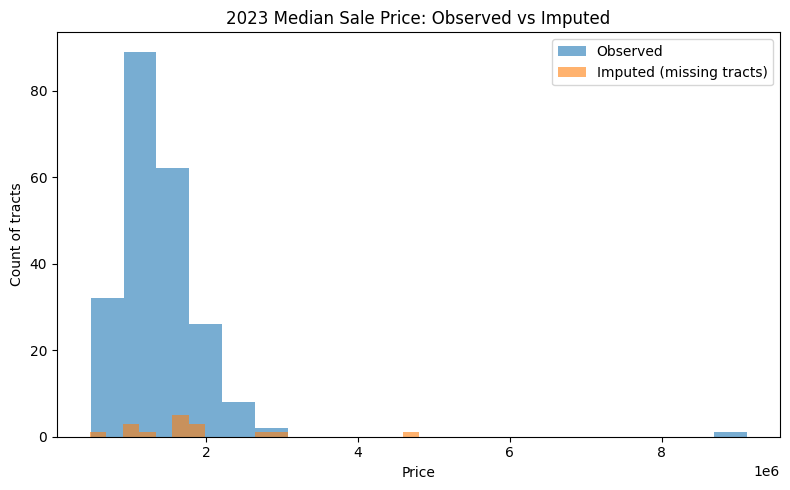

In [ ]:
import matplotlib.pyplot as plt

year = 2023
df = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{year}_enriched_IMPUTED.csv')
mask_obs = df['Median_Sale_Price_Actual'].notna() & (df['Sales_Count'] > 0)
mask_imp = ~mask_obs

plt.figure(figsize=(8,5))
plt.hist(df.loc[mask_obs, 'Median_Sale_Price_Actual'], bins=20, alpha=0.6, label='Observed')
plt.hist(df.loc[mask_imp, 'Imputed_Median_Sale_Price_Actual'], bins=20, alpha=0.6, label='Imputed (missing tracts)')
plt.legend()
plt.title(f'{year} Median Sale Price: Observed vs Imputed')
plt.xlabel('Price')
plt.ylabel('Count of tracts')
plt.tight_layout()
plt.show()


In [ ]:
for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    df = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{year}_enriched_IMPUTED.csv')
    df['Median_Value_Imputed_ACS'] = pd.to_numeric(df['Median_Value_Imputed_ACS'], errors='coerce')
    df['Imputed_Median_Sale_Price_Actual'] = pd.to_numeric(df['Imputed_Median_Sale_Price_Actual'], errors='coerce')

    mask = df['Median_Value_Imputed_ACS'].notna() & df['Imputed_Median_Sale_Price_Actual'].notna()

    ratio = df.loc[mask, 'Imputed_Median_Sale_Price_Actual'] / df.loc[mask, 'Median_Value_Imputed_ACS']
    print(f"\n{year}: consistency with ACS")
    print(f"  N = {mask.sum()}")
    print(f"  Mean price/ACS ratio: {ratio.mean():.2f}")
    print(f"  Median price/ACS ratio: {ratio.median():.2f}")
    print(f"  Min ratio: {ratio.min():.2f}, Max ratio: {ratio.max():.2f}")



2018: consistency with ACS
  N = 236
  Mean price/ACS ratio: 1.99
  Median price/ACS ratio: 1.08
  Min ratio: 0.30, Max ratio: 117.50

2019: consistency with ACS
  N = 236
  Mean price/ACS ratio: 3.35
  Median price/ACS ratio: 1.02
  Min ratio: 0.49, Max ratio: 255.46

2020: consistency with ACS
  N = 236
  Mean price/ACS ratio: 2.38
  Median price/ACS ratio: 1.09
  Min ratio: 0.39, Max ratio: 203.35

2021: consistency with ACS
  N = 236
  Mean price/ACS ratio: 3.33
  Median price/ACS ratio: 1.25
  Min ratio: 0.63, Max ratio: 186.07

2022: consistency with ACS
  N = 236
  Mean price/ACS ratio: 2.85
  Median price/ACS ratio: 1.40
  Min ratio: 0.55, Max ratio: 287.08

2023: consistency with ACS
  N = 236
  Mean price/ACS ratio: 1.57
  Median price/ACS ratio: 1.37
  Min ratio: 0.54, Max ratio: 13.84


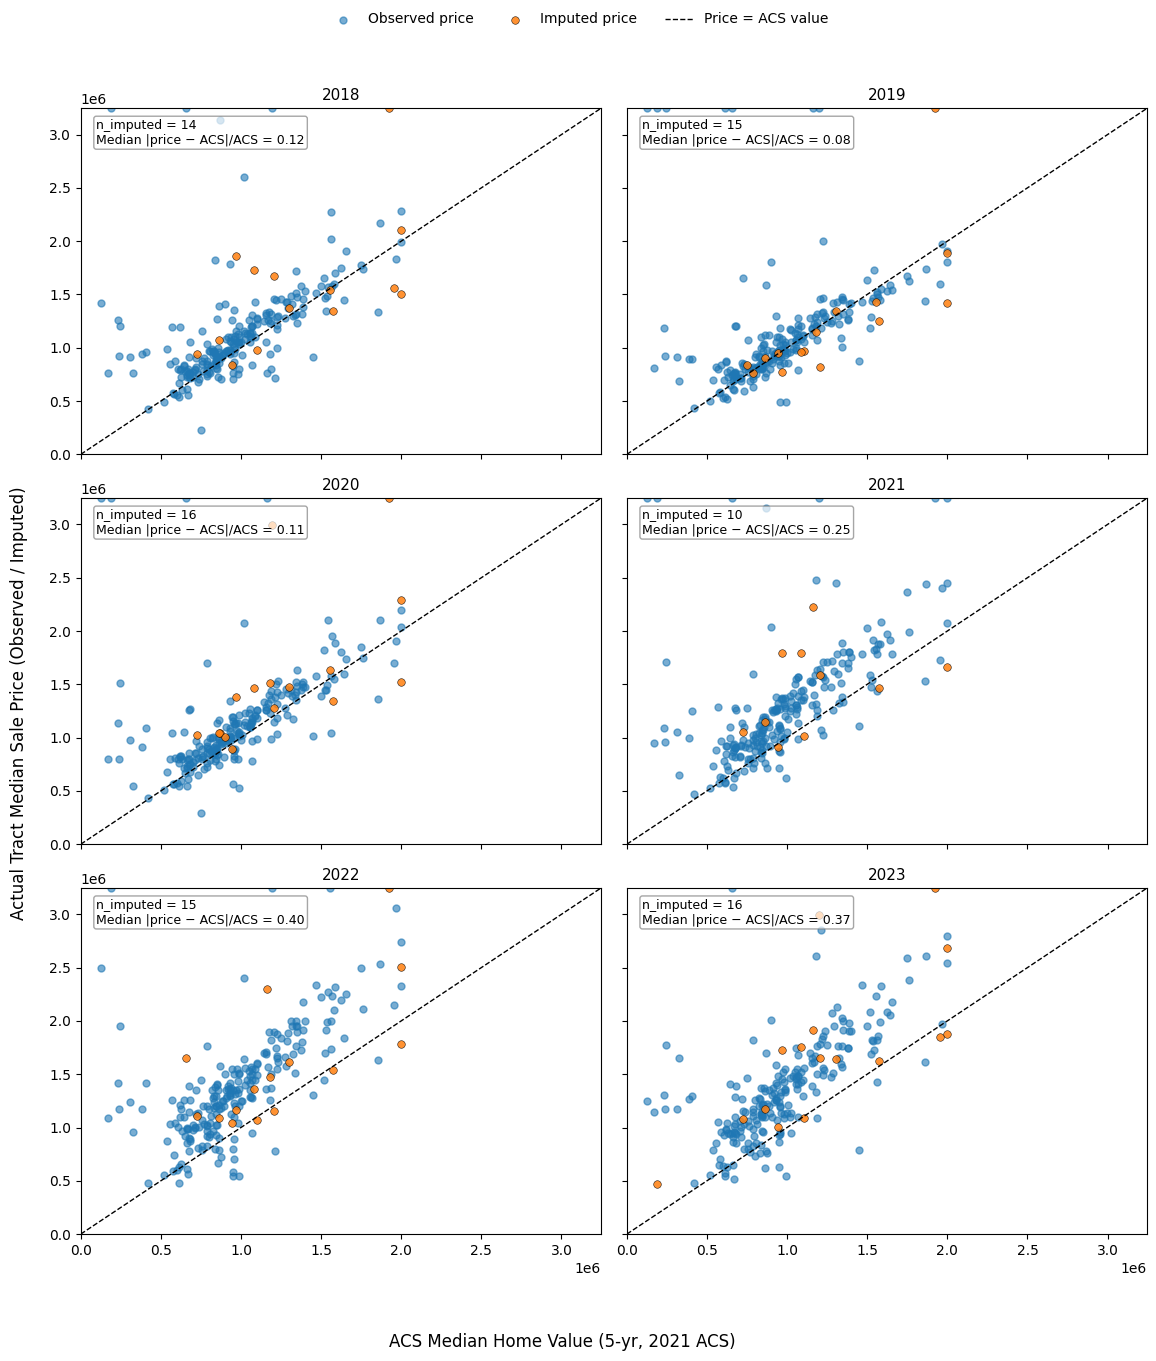

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

def load_year(year):
    df = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{year}_enriched_IMPUTED.csv')
    df['ACS'] = pd.to_numeric(df['Median_Value_Imputed_ACS'], errors='coerce')
    df['Price_obs'] = pd.to_numeric(df['Median_Sale_Price_Actual'], errors='coerce')
    df['Price_imp'] = pd.to_numeric(df['Imputed_Median_Sale_Price_Actual'], errors='coerce')
    df['Sales_Count'] = pd.to_numeric(df['Sales_Count'], errors='coerce').fillna(0)
    return df

# Common upper bound for axes (99th percentile of ACS/price)
all_vals = []
for y in YEARS:
    df = load_year(y)
    mask_valid = df['ACS'].notna() & df['Price_imp'].notna()
    all_vals.append(df.loc[mask_valid, 'ACS'])
    all_vals.append(df.loc[mask_valid, 'Price_imp'])
all_vals = pd.concat(all_vals)
upper = all_vals.quantile(0.99)

fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharex=True, sharey=True)
axes = axes.ravel()

for i, year in enumerate(YEARS):
    ax = axes[i]
    df = load_year(year)

    mask_valid = df['ACS'].notna() & df['Price_imp'].notna()
    df = df[mask_valid].copy()

    # Clip for plotting only
    df['ACS_clip']   = df['ACS'].clip(upper=upper)
    df['Price_obs_clip'] = df['Price_obs'].clip(upper=upper)
    df['Price_imp_clip'] = df['Price_imp'].clip(upper=upper)

    mask_imputed = df['Price_obs'].isna() | (df['Sales_Count'] == 0)

    # Observed points
    ax.scatter(
        df[~mask_imputed]['ACS_clip'],
        df[~mask_imputed]['Price_obs_clip'],
        alpha=0.6, s=25,
        label='Observed price' if i == 0 else "",
        color='tab:blue'
    )
    # Imputed points
    ax.scatter(
        df[mask_imputed]['ACS_clip'],
        df[mask_imputed]['Price_imp_clip'],
        alpha=0.85, s=30,
        label='Imputed price' if i == 0 else "",
        color='tab:orange', edgecolor='k', linewidth=0.4
    )

    # 45° line (Price = ACS)
    ax.plot([0, upper], [0, upper], 'k--', linewidth=1,
            label='Price = ACS value' if i == 0 else "")

    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_title(f'{year}', fontsize=11)

    # ---- Annotation: n_imputed and median absolute deviation from ACS ----
    n_imputed = int(mask_imputed.sum())
    # final price: observed where present, imputed otherwise
    final_price = df['Price_imp']
    mad_pct = np.median(np.abs(final_price - df['ACS']) / df['ACS'])

    text = f"n_imputed = {n_imputed}\nMedian |price − ACS|/ACS = {mad_pct:.2f}"
    ax.text(
        0.03, 0.97, text,
        transform=ax.transAxes,
        fontsize=9,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7)
    )

fig.text(0.5, 0.04, 'ACS Median Home Value (5‑yr, 2021 ACS)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Actual Tract Median Sale Price (Observed / Imputed)',
         va='center', rotation='vertical', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)

plt.tight_layout(rect=[0.06, 0.08, 1, 0.95])
plt.show()


Saved figure to /content/drive/MyDrive/San_Jose_Housing/acs_vs_price_scatter_6panel.png


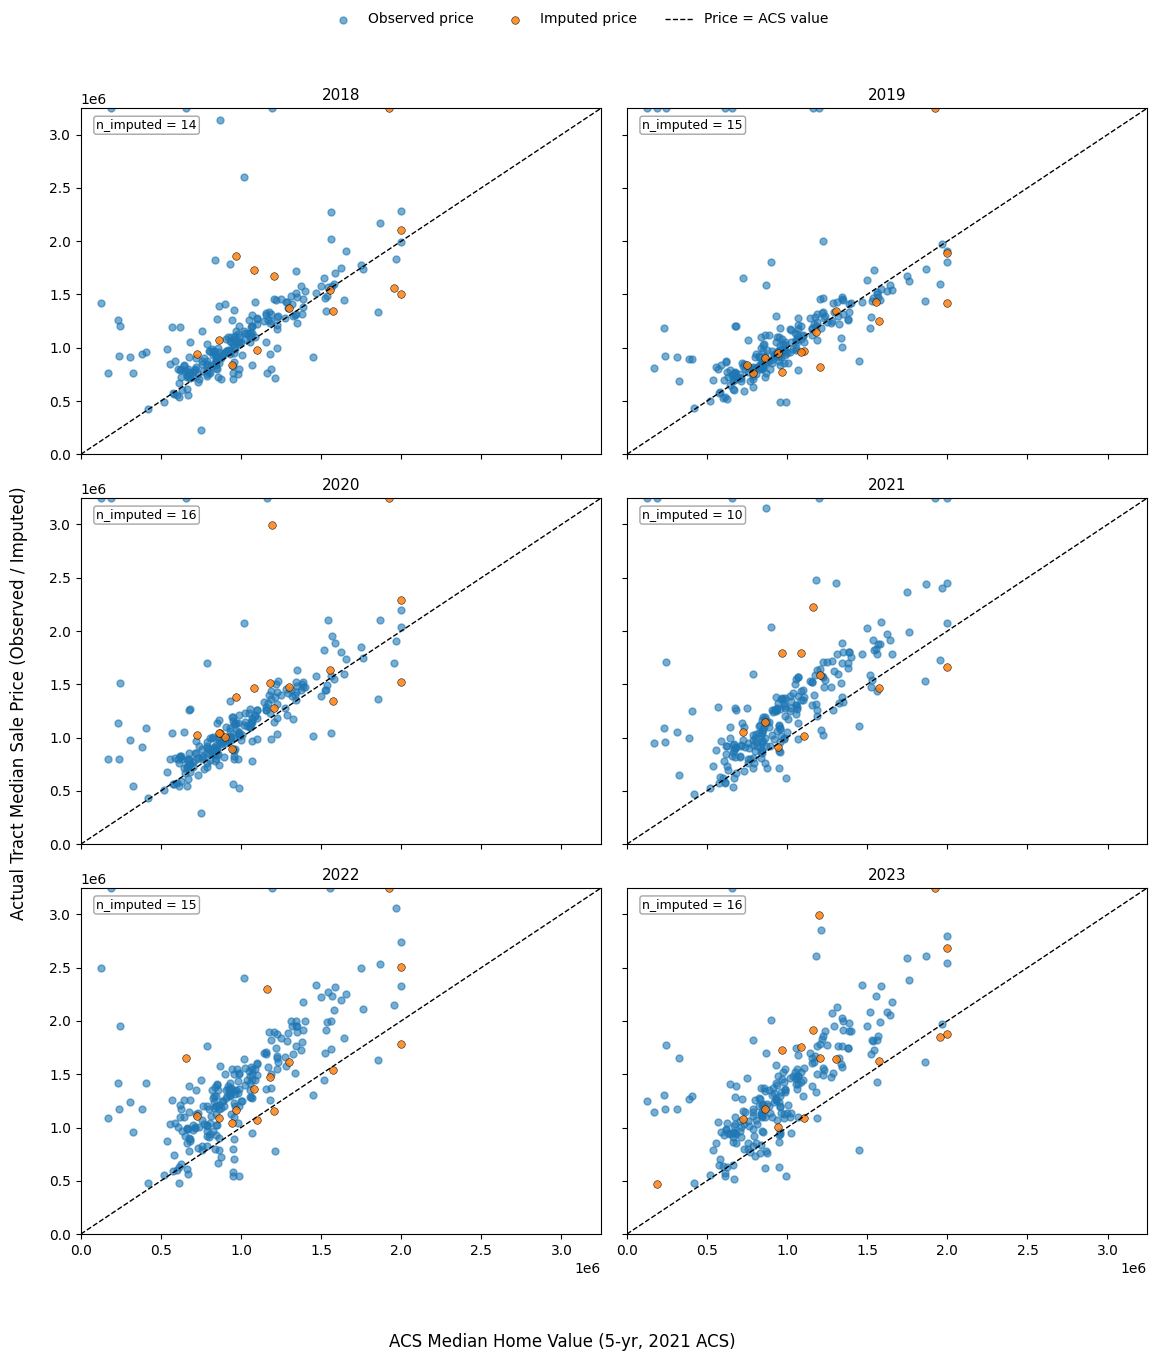

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

def load_year(year):
    df = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{year}_enriched_IMPUTED.csv')
    df['ACS'] = pd.to_numeric(df['Median_Value_Imputed_ACS'], errors='coerce')
    df['Price_obs'] = pd.to_numeric(df['Median_Sale_Price_Actual'], errors='coerce')
    df['Price_imp'] = pd.to_numeric(df['Imputed_Median_Sale_Price_Actual'], errors='coerce')
    df['Sales_Count'] = pd.to_numeric(df['Sales_Count'], errors='coerce').fillna(0)
    return df

# Common upper bound for axes (99th percentile)
all_vals = []
for y in YEARS:
    df = load_year(y)
    mask_valid = df['ACS'].notna() & df['Price_imp'].notna()
    all_vals.append(df.loc[mask_valid, 'ACS'])
    all_vals.append(df.loc[mask_valid, 'Price_imp'])
all_vals = pd.concat(all_vals)
upper = all_vals.quantile(0.99)

fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharex=True, sharey=True)
axes = axes.ravel()

for i, year in enumerate(YEARS):
    ax = axes[i]
    df = load_year(year)

    mask_valid = df['ACS'].notna() & df['Price_imp'].notna()
    df = df[mask_valid].copy()

    df['ACS_clip']       = df['ACS'].clip(upper=upper)
    df['Price_obs_clip'] = df['Price_obs'].clip(upper=upper)
    df['Price_imp_clip'] = df['Price_imp'].clip(upper=upper)

    mask_imputed = df['Price_obs'].isna() | (df['Sales_Count'] == 0)

    ax.scatter(
        df[~mask_imputed]['ACS_clip'],
        df[~mask_imputed]['Price_obs_clip'],
        alpha=0.6, s=25,
        label='Observed price' if i == 0 else "",
        color='tab:blue'
    )
    ax.scatter(
        df[mask_imputed]['ACS_clip'],
        df[mask_imputed]['Price_imp_clip'],
        alpha=0.85, s=30,
        label='Imputed price' if i == 0 else "",
        color='tab:orange', edgecolor='k', linewidth=0.4
    )

    ax.plot([0, upper], [0, upper], 'k--', linewidth=1,
            label='Price = ACS value' if i == 0 else "")

    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_title(f'{year}', fontsize=11)

    n_imputed = int(mask_imputed.sum())
    ax.text(
        0.03, 0.97, f"n_imputed = {n_imputed}",
        transform=ax.transAxes,
        fontsize=9,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7)
    )

fig.text(0.5, 0.04, 'ACS Median Home Value (5‑yr, 2021 ACS)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Actual Tract Median Sale Price (Observed / Imputed)',
         va='center', rotation='vertical', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)

plt.tight_layout(rect=[0.06, 0.08, 1, 0.95])

# Save before showing
out_path = f'{BASE_PATH}acs_vs_price_scatter_6panel.png'
plt.savefig(out_path, dpi=300)
print(f"Saved figure to {out_path}")

plt.show()


In [ ]:
import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

# Columns that were only needed for the regression / imputation step
TEMP_COLS = [
    'log_ACS_Value',
    'log_Median_Income',
    'log_Housing_Density',
    'Pred_Log_Price_2018',
    'Pred_Log_Price_2019',
    'Pred_Log_Price_2020',
    'Pred_Log_Price_2021',
    'Pred_Log_Price_2022',
    'Pred_Log_Price_2023',
    'Sale_Price_Imputed_Flag',  # only if it exists
]

for year in YEARS:
    in_path  = os.path.join(BASE_PATH, f'census_tract_analysis_{year}_enriched_IMPUTED.csv')
    out_path = os.path.join(BASE_PATH, f'census_tract_analysis_{year}_enriched_with_imputed.csv')

    df = pd.read_csv(in_path)

    # Drop temporary/model columns if present
    drop_now = [c for c in TEMP_COLS if c in df.columns]
    df = df.drop(columns=drop_now)

    # Ensure imputed column is right after the original price column
    if 'Median_Sale_Price_Actual' in df.columns and 'Imputed_Median_Sale_Price_Actual' in df.columns:
        cols = df.columns.tolist()
        cols.remove('Imputed_Median_Sale_Price_Actual')
        idx = cols.index('Median_Sale_Price_Actual')
        cols.insert(idx + 1, 'Imputed_Median_Sale_Price_Actual')
        df = df[cols]

    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}  (columns: {len(df.columns)})")


Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2018_enriched_with_imputed.csv  (columns: 73)
Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2019_enriched_with_imputed.csv  (columns: 73)
Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2020_enriched_with_imputed.csv  (columns: 73)
Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2021_enriched_with_imputed.csv  (columns: 73)
Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2022_enriched_with_imputed.csv  (columns: 73)
Saved: /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2023_enriched_with_imputed.csv  (columns: 73)


In [ ]:
import pandas as pd

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'

COLUMN_EXPLANATIONS = {
    'Census_Tract_Code': ("Unique 6-digit code identifying the Census tract.", "Census shapefile"),
    'FIPS_Code': ("Full federal tract identifier (state + county + tract).", "Census shapefile"),
    'Year': ("Reporting year of the dataset.", "Analysis year"),
    'Jurisdiction': ("City or jurisdiction associated with the tract.", "Census/Municipal data"),
    'PUMA': ("Public Use Microdata Area for ACS/PUMS analysis.", "Census PUMA boundaries"),

    # Sales and prices
    'Sales_Count': ("Number of actual property sales in tract and year.", "Property transactions"),
    'Median_Sale_Price_Actual': ("Actual median sale price from matched sales for tract/year. NaN if no sales recorded.", "Property transactions"),
    'Imputed_Median_Sale_Price_Actual': ("Final tract median sale price. Uses actual median where observed; otherwise imputed from ACS home values/incomes, LODES job metrics, and neighboring-year sale prices.", "Imputed from ACS/LODES/Property transactions"),
    'Median_Price_Per_SqFt_Actual': ("Actual median price per square foot from sales.", "Property transactions"),
    'Median_Square_Feet_Actual': ("Actual median size (square feet) of sold homes.", "Property transactions"),
    'Median_Bedrooms_Actual': ("Actual median bedroom count of sold homes.", "Property transactions"),
    'Median_Bathrooms_Actual': ("Actual median bathroom count of sold homes.", "Property transactions"),

    # Income / rents / values
    'Median_Income_Households_Previous_Year': ("Median household income for previous year.", "ACS 5-year estimates"),
    'Median_Value_Imputed_ACS': ("Median home value for tract, adjusted from ACS 5-year estimates.", "ACS 5-year estimates (imputed)"),
    'Median_Gross_Rent_Imputed_ACS': ("Median gross rent for tract, adjusted from ACS 5-year estimates.", "ACS 5-year estimates (imputed)"),

    # Demographics & densities
    'Persons_Total': ("Total population in tract.", "ACS 5-year estimates"),
    'Households_Total': ("Total households in tract.", "ACS 5-year estimates"),
    'Avg_Nb_People_Households': ("Average household size.", "ACS 5-year estimates"),
    'Median_Age_Persons': ("Median age of persons in tract.", "ACS 5-year estimates"),
    'Density_People_Land_km2': ("Population density (persons per square kilometer of land).", "Calculated from ACS"),
    'Density_Housing_Land_km2': ("Housing unit density (units per square kilometer of land).", "Calculated from ACS"),

    # Income cutoffs & shares
    'VLI_Cutoff_Estimated': ("Estimated Very Low-Income cutoff in dollars based on HCD income limits.", "HCD income limits (estimated)"),
    'LI_Cutoff_Estimated': ("Estimated Low-Income cutoff in dollars based on HCD income limits.", "HCD income limits (estimated)"),
    'MOD_Cutoff_Estimated': ("Estimated Moderate-Income cutoff in dollars based on HCD income limits.", "HCD income limits (estimated)"),
    'VLI_Households_Prop': ("Proportion of households in Very Low-Income category.", "ACS 5-year estimates"),
    'LI_Households_Prop': ("Proportion of households in Low-Income category.", "ACS 5-year estimates"),
    'MOD_Households_Prop': ("Proportion of households in Moderate-Income category.", "ACS 5-year estimates"),
    'AMOD_Households_Prop': ("Proportion of households in Above Moderate-Income category.", "ACS 5-year estimates"),
    'Estimated_Income_Category_Census': ("Overall tract income category classification based on ACS/HCD data.", "Calculated from ACS and HCD"),

    # Affordability ratios
    'Actual_Price_To_Income_Ratio': ("Ratio of actual median sale price to median household income.", "Calculated from Property transactions and ACS"),
    'ACS_Estimated_Price_To_Income_Ratio': ("Ratio of ACS-imputed home value to median household income.", "Calculated from ACS"),

    # Additional demographic proportions
    'Prop_Persons_Income_Below_Poverty_Level': ("Proportion of persons with income below the poverty level.", "ACS 5-year estimates"),
    'Prop_Persons_60_years_and_over': ("Proportion of persons aged 60 or older.", "ACS 5-year estimates"),
    'Prop_Labor_Force_Unemployed': ("Unemployment rate for the labor force.", "ACS 5-year estimates"),
    'Prop_Commuting_Work_Over_45_min': ("Proportion of workers with commute time over 45 minutes.", "ACS 5-year estimates"),

    # Housing stock & BR / pipeline
    'Housing_Units_Total': ("Total housing units in tract.", "ACS 5-year estimates"),
    'Total_Units_BR': ("Total housing units in Builder's Remedy projects in tract.", "HCD APR"),
    'Builders_Remedy_Intensity_Pct': ("Builder's Remedy units as a percent of existing housing units.", "Calculated from HCD APR and ACS"),
    'Nb_Units_Tot_Proposed': ("Total housing units proposed in development pipeline.", "HCD APR"),
    'Nb_Submissions': ("Number of development submissions (projects) in tract.", "HCD APR"),
    'Pipeline_Supply_Pct': ("Proposed units as a percent of existing housing units.", "Calculated from HCD APR and ACS"),
    'Development_Approval_Rate_Pct': ("Percent of proposed units that were approved.", "Calculated from HCD APR"),
    'Land_Area_km2': ("Land area of tract in square kilometers.", "Census geography"),

    # Workplace jobs (LODES WAC)
    'Total_Jobs': ("Total jobs located in tract (workplace area).", "LODES WAC"),
    'High_Wage_Jobs': ("Number of high-wage jobs located in tract (LODES high-wage category).", "LODES WAC"),
    'Jobs_Professional_Tech': ("Number of professional and technical jobs in tract.", "LODES WAC"),
    'Jobs_Finance': ("Number of finance sector jobs in tract.", "LODES WAC"),
    'Jobs_Information': ("Number of information sector jobs in tract.", "LODES WAC"),
    'Jobs_Manufacturing': ("Number of manufacturing jobs in tract.", "LODES WAC"),
    'Jobs_Retail': ("Number of retail jobs in tract.", "LODES WAC"),
    'Jobs_Healthcare': ("Number of healthcare jobs in tract.", "LODES WAC"),
    'High_Wage_Job_Share_Pct': ("High-wage jobs as a percent of total jobs.", "Calculated from LODES WAC"),
    'Tech_Job_Share_Pct': ("Professional/tech jobs as a percent of total jobs.", "Calculated from LODES WAC"),
    'White_Collar_Job_Share_Pct': ("White-collar jobs as a percent of total jobs.", "Calculated from LODES WAC"),
    'Jobs_Per_Capita': ("Jobs per resident (Total jobs / Persons_Total).", "Calculated from LODES WAC and ACS"),
    'Jobs_Per_Housing_Unit': ("Jobs per housing unit (Total jobs / Housing_Units_Total).", "Calculated from LODES WAC and ACS"),
    'Job_Density_Per_km2': ("Job density (jobs per square kilometer).", "Calculated from LODES WAC"),

    # Resident workers (LODES RAC)
    'Resident_Workers_Total': ("Total resident workers living in tract.", "LODES RAC"),
    'Resident_Workers_High_Wage': ("Resident workers in high-wage jobs (LODES high-wage category).", "LODES RAC"),
    'Resident_Workers_Prof_Tech': ("Resident workers in professional/tech occupations.", "LODES RAC"),
    'Resident_High_Wage_Share_Pct': ("Proportion of resident workers in high-wage jobs.", "Calculated from LODES RAC"),
    'Resident_Tech_Worker_Share_Pct': ("Proportion of resident workers in professional/tech jobs.", "Calculated from LODES RAC"),
    'Jobs_Housing_Balance_Ratio': ("Ratio of workplace jobs to resident workers (jobs-housing balance indicator).", "Calculated from LODES WAC and RAC"),
    'Wealth_Retention_Ratio': ("Ratio of resident high-wage workers to workplace high-wage jobs (proxy for local economic capture).", "Calculated from LODES WAC and RAC"),
    'Tech_Resident_Workplace_Ratio': ("Ratio of resident tech workers to workplace tech jobs.", "Calculated from LODES WAC and RAC"),
    'Resident_Employment_Rate_Pct': ("Employment rate among tract residents.", "Calculated from LODES RAC and ACS"),
}

df_explain = pd.DataFrame(
    [{'Column': col, 'Description': desc, 'Source': source}
     for col, (desc, source) in COLUMN_EXPLANATIONS.items()]
)
out_path = f'{BASE_PATH}essential_data_dictionary.csv'
df_explain.to_csv(out_path, index=False)
print(f"✅ Data dictionary saved: {out_path}")
print(f"   Total fields documented: {len(df_explain)}")


✅ Data dictionary saved: /content/drive/MyDrive/San_Jose_Housing/essential_data_dictionary.csv
   Total fields documented: 66


In [ ]:
import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

# All PUMA-related columns we want to drop (keep only "PUMA")
PUMA_DROP_COLS = [
    'PUMA_Total_Households_Est',
    'PUMA_Median_HH_Income',
    'PUMA_Median_Home_Value',
    'PUMA_Pct_Owner_No_Mortgage',
    'PUMA_Total_Workers_Est',
    'PUMA_Tech_Workers_Est',
    'PUMA_Tech_Worker_Pct'
]

for year in YEARS:
    path = os.path.join(BASE_PATH, f'census_tract_analysis_{year}_enriched_with_imputed.csv')
    df = pd.read_csv(path)

    drop_now = [c for c in PUMA_DROP_COLS if c in df.columns]
    if drop_now:
        df = df.drop(columns=drop_now)

    df.to_csv(path, index=False)
    print(f"Updated (removed PUMA summaries): {path}  -> {len(df.columns)} columns")


Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2018_enriched_with_imputed.csv  -> 66 columns
Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2019_enriched_with_imputed.csv  -> 66 columns
Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2020_enriched_with_imputed.csv  -> 66 columns
Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2021_enriched_with_imputed.csv  -> 66 columns
Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2022_enriched_with_imputed.csv  -> 66 columns
Updated (removed PUMA summaries): /content/drive/MyDrive/San_Jose_Housing/census_tract_analysis_2023_enriched_with_imputed.csv  -> 66 columns


2018: 14 tracts missing sales or price data
2019: 15 tracts missing sales or price data
2020: 16 tracts missing sales or price data
2021: 10 tracts missing sales or price data
2022: 15 tracts missing sales or price data
2023: 16 tracts missing sales or price data

Tracts missing in more than one year: (17)
[507402, 507807, 507808, 505901, 505902, 505012, 505013, 512054, 512311, 512200, 502603, 502604, 506701, 513500, 508004, 512100, 504424]


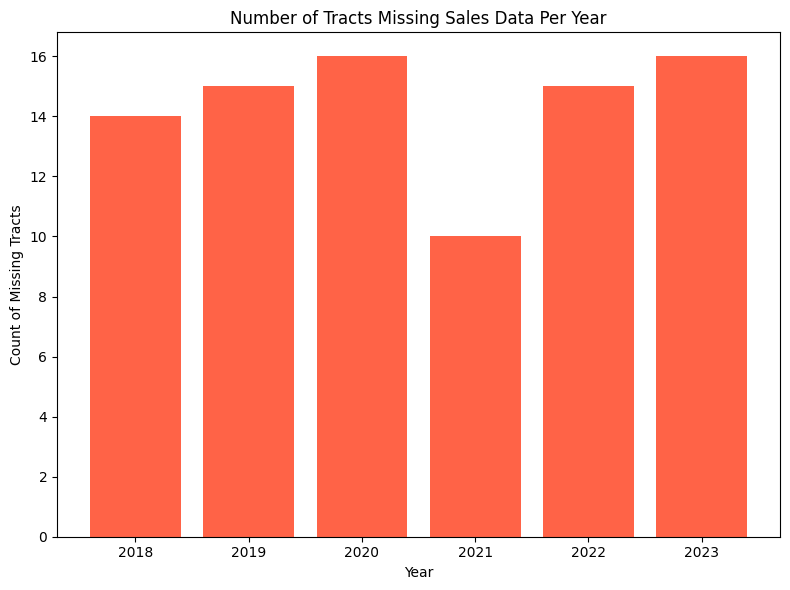

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'

# Track missing tracts per year
missing_tracts_per_year = {}

for year in YEARS:
    df = pd.read_csv(f'{BASE_PATH}census_tract_analysis_{year}_enriched.csv')
    missing = df[(df['Sales_Count'] == 0) | (df['Median_Sale_Price_Actual'].isna())]['Census_Tract_Code'].unique().tolist()
    missing_tracts_per_year[year] = set(missing)
    print(f"{year}: {len(missing)} tracts missing sales or price data")

# Find repeat-missing tracts
all_missing_tracts = set.union(*missing_tracts_per_year.values())
repeat_missing = {tract: 0 for tract in all_missing_tracts}

for tract in all_missing_tracts:
    repeat_missing[tract] = sum(tract in year_set for year_set in missing_tracts_per_year.values())

repeat_missed_tracts = [t for t, count in repeat_missing.items() if count > 1]

print(f"\nTracts missing in more than one year: ({len(repeat_missed_tracts)})")
print(repeat_missed_tracts)

# Bar chart: number of missing tracts per year
year_bar = {year: len(missing_tracts_per_year[year]) for year in YEARS}
plt.figure(figsize=(8,6))
plt.bar(year_bar.keys(), year_bar.values(), color='tomato')
plt.title('Number of Tracts Missing Sales Data Per Year')
plt.ylabel('Count of Missing Tracts')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}missing_tracts_barplot.png', dpi=300)
plt.show()


##Missing tract sales map

In [ ]:
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
import numpy as np


YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
BASE_PATH = '/content/drive/MyDrive/San_Jose_Housing/'
SHAPEFILE_PATH = BASE_PATH + 'SanJose_2020_Census_Tract.shp'
OUTPUT_HTML = BASE_PATH + 'san_jose_yearwise_imputed_prices_map.html'

# ---------- load and prep geometry ----------
gdf = gpd.read_file(SHAPEFILE_PATH)
gdf['Census_Tract_Code'] = gdf['FIPSCODE'].astype(str).str[-6:]
gdf = gdf.to_crs('EPSG:4326')

if 'Land_Area_km2' not in gdf.columns:
    gdf_proj = gdf.to_crs('EPSG:3310')
    gdf['Land_Area_km2'] = gdf_proj.geometry.area / 1e6

max_area_km2 = 7
gdf = gdf[gdf['Land_Area_km2'] <= max_area_km2].copy()

center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='cartodbpositron',
    control_scale=True
)

# ---------- legend / info box ----------
latest_year = YEARS[-1]
info_html = f"""
<div style="
    position: fixed;
    top: 60px; left: 60px; width: 320px;
    z-index:9999; font-size:14px;
    background-color: white;
    border-radius: 4px;
    border: 1px solid #777;
    padding: 8px 10px;
    box-shadow: 1px 1px 6px rgba(0,0,0,0.3);
">
  <b>San José Tract Median Price Map</b><br>
  <span style="font-size:13px;">
    • Default year: <b>{latest_year}</b><br>
    • Orange tracts: at least one sale (median price is observed).<br>
    • Grey tracts: no sales; median price is <i>imputed</i>.<br>
    Use the layer control (top right) to switch year.
  </span>
</div>
"""
m.get_root().html.add_child(folium.Element(info_html))

# Tracts to drop for visualization
EXCLUDE_TRACTS = ['505012', '505013', '505014', '505015', '512311']

# ---------- layers by year (core tracts only) ----------
for year in YEARS:
    enriched_csv = f'{BASE_PATH}census_tract_analysis_{year}_enriched_with_imputed.csv'
    df = pd.read_csv(enriched_csv)
    df['Census_Tract_Code'] = df['Census_Tract_Code'].astype(str).str.strip()

    # keep only core San José tracts (e.g. at least 50% of area inside city)
    if 'Proportion_Census_Tract_Covered' in df.columns:
        df = df[df['Proportion_Census_Tract_Covered'] >= 0.5].copy()

    # explicitly drop fringe tracts that break the visual boundary
    df = df[~df['Census_Tract_Code'].isin(EXCLUDE_TRACTS)].copy()

    year_gdf = gdf.merge(df, on='Census_Tract_Code', how='inner')

    # convert datetime cols to str for Folium
    for col in year_gdf.columns:
        if col == 'geometry':
            continue
        if np.issubdtype(year_gdf[col].dtype, np.datetime64):
            year_gdf[col] = year_gdf[col].astype(str)

    def style_function(feature):
        sales = feature['properties'].get('Sales_Count', None)
        # orange when there is at least one observed sale, grey when fully imputed
        if sales is None or sales == 0 or pd.isna(sales):
            return {'fillColor': '#d9d9d9', 'color': '#555',
                    'weight': 0.6, 'fillOpacity': 0.35}
        else:
            return {'fillColor': '#fdae61', 'color': '#555',
                    'weight': 0.9, 'fillOpacity': 0.7}

    def popup_function(feature):
        code = feature['properties']['Census_Tract_Code']
        sales = feature['properties'].get('Sales_Count', None)
        price_final = feature['properties'].get('Imputed_Median_Sale_Price_Actual', None)
        price_obs = feature['properties'].get('Median_Sale_Price_Actual', None)

        if price_final is None or pd.isna(price_final):
            return None

        # label whether price is observed or imputed
        if sales is not None and not pd.isna(sales) and int(sales) > 0 and pd.notna(price_obs):
            source_label = "Observed median sale price"
        else:
            source_label = "Imputed median sale price"

        popup_html = f"""
        <div style="font-family: Arial; font-size: 13px;">
          <b>Census tract:</b> {code}<br>
          <b>Year:</b> {year}<br>
          <b>Sales count:</b> {int(sales) if sales is not None and not pd.isna(sales) else 0}<br>
          <b>{source_label}:</b> {('${:,.0f}'.format(price_final)
             if price_final and price_final > 0 else 'N/A')}
        </div>
        """
        return folium.Popup(popup_html, max_width=260)

    layer = folium.GeoJson(
        year_gdf,
        name=f"Year {year}",
        show=(year == latest_year),
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=['Census_Tract_Code', 'Sales_Count', 'Imputed_Median_Sale_Price_Actual'],
            aliases=['Tract', 'Sales count', 'Median sale price (obs/imputed)'],
            localize=True
        ),
        popup=popup_function,
        highlight_function=lambda x: {'weight': 2, 'color': 'blue'}
    )
    layer.add_to(m)

folium.LayerControl(position='topright', collapsed=False).add_to(m)
plugins.Fullscreen(position='topleft').add_to(m)

m.save(OUTPUT_HTML)
print(f"\nInteractive imputed-price map saved: {OUTPUT_HTML}")



Interactive imputed-price map saved: /content/drive/MyDrive/San_Jose_Housing/san_jose_yearwise_imputed_prices_map.html
